In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
RAW_DATA_DIR = Path("../data/raw")

In [3]:
# load all datasets

with open(RAW_DATA_DIR / "recovery.json") as f: 
    recovery_raw = json.load(f)

with open(RAW_DATA_DIR / "sleep.json") as f:
    sleep_raw = json.load(f)

with open(RAW_DATA_DIR / "workouts.json") as f:
    workouts_raw = json.load(f)

with open(RAW_DATA_DIR / "cycles.json") as f:
    cycles_raw = json.load(f)

print(f"Recovery records: {len(recovery_raw)}")
print(f"Sleep records: {len(sleep_raw)}")
print(f"Workout records: {len(workouts_raw)}")
print(f"Cycle records: {len(cycles_raw)}")

Recovery records: 245
Sleep records: 259
Workout records: 381
Cycle records: 246


In [4]:
recovery_raw[0]

{'cycle_id': 1550475332,
 'sleep_id': '977c3bf6-7d11-489e-9d75-b7f1973cc48a',
 'user_id': 31526255,
 'created_at': '2026-06-06T13:18:35.860Z',
 'updated_at': '2026-06-06T13:18:35.860Z',
 'score_state': 'SCORED',
 'score': {'user_calibrating': False,
  'recovery_score': 55.0,
  'resting_heart_rate': 45.0,
  'hrv_rmssd_milli': 118.53185,
  'spo2_percentage': 96.111115,
  'skin_temp_celsius': 33.024}}

In [5]:
# peek at one record from each
print("SLEEP:")
print(list(sleep_raw[0].keys()))
print("\nSLEEP SCORE KEYS:")
print(list(sleep_raw[0]['score'].keys()))

print("\nWORKOUT:")
print(list(workouts_raw[0].keys()))

print("\nCYCLE:")
print(list(cycles_raw[0].keys()))

SLEEP:
['id', 'cycle_id', 'v1_id', 'user_id', 'created_at', 'updated_at', 'start', 'end', 'timezone_offset', 'nap', 'score_state', 'score']

SLEEP SCORE KEYS:
['stage_summary', 'sleep_needed', 'respiratory_rate', 'sleep_performance_percentage', 'sleep_consistency_percentage', 'sleep_efficiency_percentage']

WORKOUT:
['id', 'v1_id', 'user_id', 'created_at', 'updated_at', 'start', 'end', 'timezone_offset', 'sport_name', 'score_state', 'score', 'sport_id']

CYCLE:
['id', 'user_id', 'created_at', 'updated_at', 'start', 'end', 'timezone_offset', 'score_state', 'score']


In [8]:
recovery_df = pd.json_normalize(recovery_raw)

print(recovery_df.shape)
print(recovery_df.columns.tolist())

(245, 12)
['cycle_id', 'sleep_id', 'user_id', 'created_at', 'updated_at', 'score_state', 'score.user_calibrating', 'score.recovery_score', 'score.resting_heart_rate', 'score.hrv_rmssd_milli', 'score.spo2_percentage', 'score.skin_temp_celsius']


In [11]:
# normalize all datasets
sleep_df = pd.json_normalize(sleep_raw)
workouts_df = pd.json_normalize(workouts_raw)
cycles_df = pd.json_normalize(cycles_raw)

# filter to only SCORED records
recovery_df = recovery_df[recovery_df['score_state'] == 'SCORED']
sleep_df = sleep_df[sleep_df['score_state'] == 'SCORED']
workouts_df = workouts_df[workouts_df['score_state'] == 'SCORED']
cycles_df = cycles_df[cycles_df['score_state'] == 'SCORED']

# filter out naps from sleep — keep only main sleep sessions
sleep_df = sleep_df[sleep_df['nap'] == False]

print(f"Recovery after filtering: {len(recovery_df)}")
print(f"Sleep after filtering: {len(sleep_df)}")
print(f"Workouts after filtering: {len(workouts_df)}")
print(f"Cycles after filtering: {len(cycles_df)}")

Recovery after filtering: 245
Sleep after filtering: 245
Workouts after filtering: 381
Cycles after filtering: 246


In [13]:
recovery_df['created_at'] = pd.to_datetime(recovery_df['created_at'])
cycles_df['start'] = pd.to_datetime(cycles_df['start'])
sleep_df['start'] = pd.to_datetime(sleep_df['start'])
sleep_df['end'] = pd.to_datetime(sleep_df['end'])
workouts_df['start'] = pd.to_datetime(workouts_df['start'])
workouts_df['end'] = pd.to_datetime(workouts_df['end'])

# add a clean date column to recovery - this is our primary index
recovery_df['date'] = recovery_df['created_at'].dt.date
recovery_df = recovery_df.sort_values('date').reset_index(drop=True)

print(f"Date range: {recovery_df['date'].min()} to {recovery_df['date'].max()}")
print(f"Total days: {(recovery_df['date'].max() - recovery_df['date'].min()).days}")

Date range: 2025-10-05 to 2026-06-06
Total days: 244


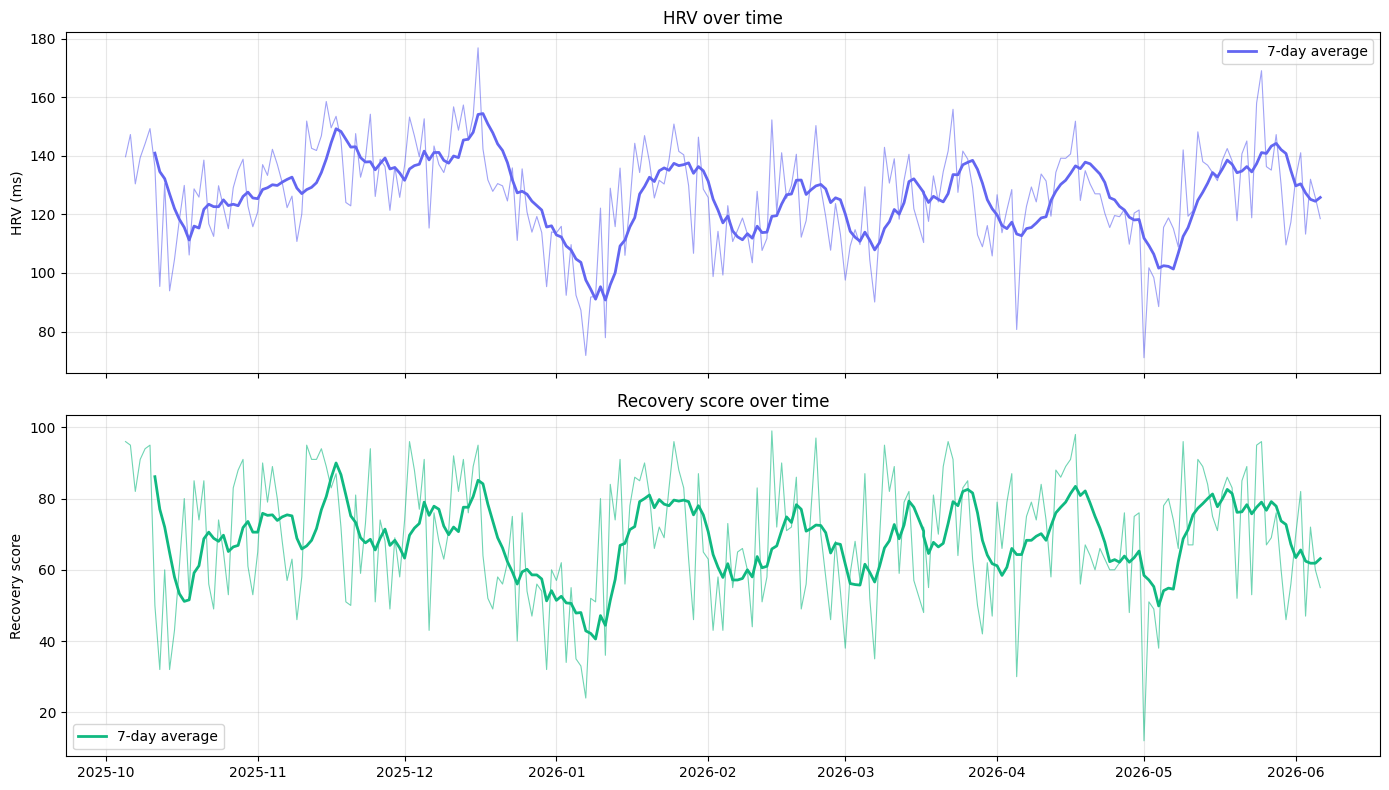

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# HRV over time
ax1.plot(recovery_df['date'], recovery_df['score.hrv_rmssd_milli'], 
         color='#6366f1', linewidth=0.8, alpha=0.6)
ax1.plot(recovery_df['date'], 
         recovery_df['score.hrv_rmssd_milli'].rolling(7).mean(),
         color='#6366f1', linewidth=2, label='7-day average')
ax1.set_ylabel('HRV (ms)')
ax1.set_title('HRV over time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Recovery score over time
ax2.plot(recovery_df['date'], recovery_df['score.recovery_score'],
         color='#10b981', linewidth=0.8, alpha=0.6)
ax2.plot(recovery_df['date'],
         recovery_df['score.recovery_score'].rolling(7).mean(),
         color='#10b981', linewidth=2, label='7-day average')
ax2.set_ylabel('Recovery score')
ax2.set_title('Recovery score over time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/hrv_recovery_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

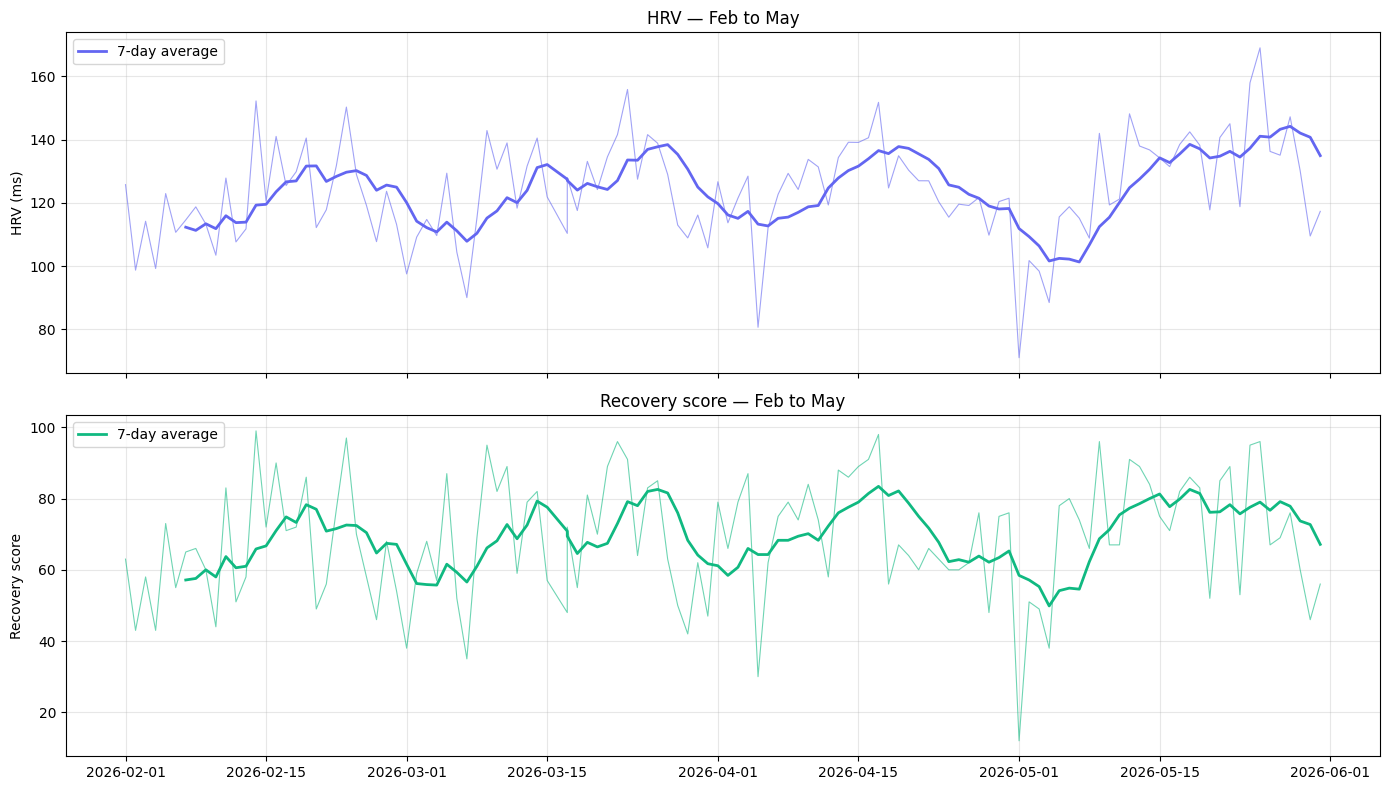

In [16]:
# zoom into feb - may to see the cycle pattern
mask = (recovery_df['date'] >= pd.to_datetime('2026-02-01').date()) & \
       (recovery_df['date'] <= pd.to_datetime('2026-05-31').date())

feb_may = recovery_df[mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(feb_may['date'], feb_may['score.hrv_rmssd_milli'],
         color='#6366f1', linewidth=0.8, alpha=0.6)
ax1.plot(feb_may['date'],
         feb_may['score.hrv_rmssd_milli'].rolling(7).mean(),
         color='#6366f1', linewidth=2, label='7-day average')
ax1.set_ylabel('HRV (ms)')
ax1.set_title('HRV — Feb to May')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(feb_may['date'], feb_may['score.recovery_score'],
         color='#10b981', linewidth=0.8, alpha=0.6)
ax2.plot(feb_may['date'],
         feb_may['score.recovery_score'].rolling(7).mean(),
         color='#10b981', linewidth=2, label='7-day average')
ax2.set_ylabel('Recovery score')
ax2.set_title('Recovery score — Feb to May')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()